In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Sigmoid Activation Function

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of Sigmoid Function

def sigmoid_derivative(x):
    return x * (1 - x)

In [3]:
# XOR Input Dataset

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# XOR Output

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

print("Input:")
print(X)

print("\nExpected Output:")
print(y)

Input:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Expected Output:
[[0]
 [1]
 [1]
 [0]]


In [4]:
# Random seed for reproducibility

np.random.seed(1)

# Input layer to hidden layer weights
weights_input_hidden = np.random.uniform(size=(2, 2))

# Hidden layer to output layer weights
weights_hidden_output = np.random.uniform(size=(2, 1))

# Biases
bias_hidden = np.random.uniform(size=(1, 2))
bias_output = np.random.uniform(size=(1, 1))

print("Initial Weights:")
print(weights_input_hidden)
print(weights_hidden_output)

Initial Weights:
[[4.17022005e-01 7.20324493e-01]
 [1.14374817e-04 3.02332573e-01]]
[[0.14675589]
 [0.09233859]]


In [5]:
# Learning rate
learning_rate = 0.1

# Number of epochs
epochs = 10000

# Store loss values
losses = []

In [6]:
# Training the Neural Network

for epoch in range(epochs):
    
    # Forward Propagation
    
    hidden_input = np.dot(X, weights_input_hidden) + bias_hidden
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, weights_hidden_output) + bias_output
    predicted_output = sigmoid(final_input)

    # Calculate Error
    
    error = y - predicted_output
    
    loss = np.mean(np.square(error))
    losses.append(loss)

    # Back Propagation
    
    d_predicted_output = error * sigmoid_derivative(predicted_output)

    error_hidden_layer = d_predicted_output.dot(weights_hidden_output.T)

    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_output)

    # Update weights and biases
    
    weights_hidden_output += hidden_output.T.dot(d_predicted_output) * learning_rate
    
    weights_input_hidden += X.T.dot(d_hidden_layer) * learning_rate

    bias_output += np.sum(d_predicted_output, axis=0, keepdims=True) * learning_rate
    
    bias_hidden += np.sum(d_hidden_layer, axis=0, keepdims=True) * learning_rate

print("Training Completed")

Training Completed


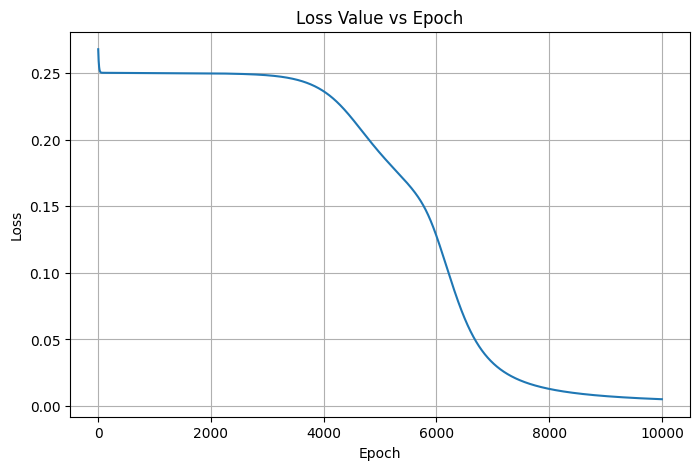

In [7]:
# Plot Loss Graph

plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Value vs Epoch")

plt.grid(True)

plt.show()

In [8]:
# Final Predictions

print("Predicted Output:")

print(predicted_output)

Predicted Output:
[[0.07304485]
 [0.93084242]
 [0.93122512]
 [0.07564609]]


In [9]:
print("X1  X2  Predicted Output")
print("-------------------------")

for i in range(len(X)):
    
    output = 1 if predicted_output[i] >= 0.5 else 0
    
    print(X[i][0], " ", X[i][1], "       ", output)

X1  X2  Predicted Output
-------------------------
0   0         0
0   1         1
1   0         1
1   1         0
